In [1]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18
from astropy.io import fits
from astropy.wcs import WCS

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs, find_objects_nearby
from desi_lowz_funcs import calc_normalized_dist, save_cutouts
from desi_lowz_funcs import find_objects_nearby, process_img, sdss_rgb
from construct_dwarf_galaxy_catalogs import process_sga_matches
from catalog_paper_plots import make_bar_pie


%load_ext autoreload
%autoreload 2


In [2]:

import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'tight',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})

MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar
    

In [3]:
# zpix_iron  =  Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/zminimal-pix-iron.fits")

In [4]:

# Path to the catalog
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
main = Table.read(filename, hdu="MAIN")

main = main[(main["DWARF_MASKBIT"] == 0)]


In [5]:
# print(len(main))

# fib_based = Table.read(filename, hdu="FIBER_BASED")


In [6]:
main[main["TARGETID"]==39627757658834718]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,IS_BGS_BRIGHT,IS_BGS_FAINT,IS_LOWZ,IS_ELG,IS_OTHER,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE,PROPERTY_SOURCE_TARGETID
int64,bytes7,bytes6,int32,float64,float64,int32,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,int32,int32,bytes13,bool,float64,float64[2],bool,bool,bool,bool,bool,bool,object,int64,bool,bytes10,int64
39627757658834718,main,bright,26253,0.006660391095060748,82918.83328406338,0,0.007832706579024018,186.59466877781506,-1.255176970553927,186.5946494639167,-1.2533945161453883,DESI J186.5946-01.2533,29.24152183532715,7.995614051818848,0.05963573044754567,16.073965072631836,15.999963760375977,16.033334732055664,19.179119110107422,19.654542922973633,20.47101402282715,0,0,COG,True,15.28721809387207,0.4738743007183075 .. 26.12926483154297,True,False,True,False,False,False,[ 2389497849315331 2402691988848642 39627757658834718 39627757658834857],39627757658834718,True,CF3_NAM,39627757658834857


In [7]:
n_assoc = np.array([len(x) for x in main["ASSOCIATED_TARGETIDS"]])

8866
430520
[ 1  2  3  4  5  6  7  8  9 10 11 12 24]


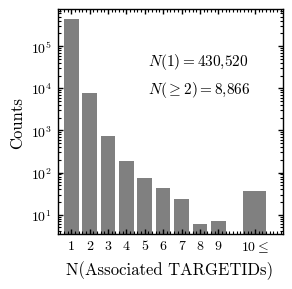

In [10]:
fig, ax = make_subplots(ncol=1, nrow=1, return_fig=True, plot_size = 2.25, col_spacing=[MARGIN_LABEL, MARGIN_PAD],
                        row_spacing=[MARGIN_LABEL, MARGIN_PAD])

vals, counts = np.unique(n_assoc, return_counts=True)

print(np.sum(counts[1:]))
print((counts[0]))
print(vals)

# split values
mask_tail = vals >= 10

# regular bins: 1..9
vals_main = vals[(vals >= 1) & (vals < 10)]
counts_main = counts[(vals >= 1) & (vals < 10)]

# tail bin: N >= 10
val_tail = 11
count_tail = counts[mask_tail].sum()

# plot regular bins
ax[0].bar(
    vals_main,
    counts_main,
    color="grey"
)

# plot tail bin (wider)
ax[0].bar(
    val_tail,
    count_tail,
    width=1.25,
    color="grey"
)

ax[0].set_yscale("log")
ax[0].set_xlim(0.25, 12.5)

# ticks: label last as >=10
ax[0].set_xticks(list(range(1, 10)) + [11])
ax[0].set_xticklabels([str(i) for i in range(1, 10)] + [r"$10\leq$"])

ax[0].set_xlabel("N(Associated TARGETIDs)")
ax[0].set_ylabel("Counts")

# ax[0].tick_params(which='major', length=7)
# ax[0].tick_params(which='minor', length=3.5)

ax[0].text(0.4,0.8-0.05,r"$N(1) = 430{,}520$",
           transform=ax[0].transAxes)

ax[0].text(0.4,0.675-0.05,r"$N(\geq 2)=8{,}866$",
           transform=ax[0].transAxes)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/nassoc_targetids.pdf")

plt.show()

In [17]:
# 163.91273037387103	2.395082279226273
# 163.91273285962214	2.395081806087309
# 163.9127325831637	2.3950820373216124
# 163.9127320643719	2.3950820097560435

# dwarf_cat[(dwarf_cat["LOG_MSTAR_M24"] < 8) & (n_assoc >5)]["RA","DEC"]

In [24]:
# https://www.legacysurvey.org/viewer/?ra=337.1084&dec=30.2924&layer=ls-dr9&zoom=14&mark=337.114053,30.280666

targetids_ifu_eg = [ 39627847874121173, 39628488239485870, 39627757658834718, 39627672602552506  ]

In [25]:
from get_associated_fibers import get_associated_tgid_info

In [49]:
cutout_ra, cutout_dec, gal_r50, sample_info, sample_ra, sample_dec = get_associated_tgid_info(targetids_ifu_eg[1], main, zpix_iron)

In [45]:
get_associated_tgid_info(targetids_ifu_eg[2], main, zpix_iron)

(186.5945389843334,
 -1.2552527092353434,
 15.25578498840332,
 ['BGS_FAINT', 'OTHER', 'OTHER', 'ELG'],
 [186.5946494639167,
  186.59346904318573,
  186.59563286242405,
  186.5996561725144],
 [-1.2533945161453883,
  -1.2575320964764913,
  -1.2516281445019446,
  -1.2522257996807036])

In [46]:
get_associated_tgid_info(targetids_ifu_eg[3], main, zpix_iron)

(152.75485257391395,
 -4.69530047723724,
 94.6119155883789,
 ['BGS_BRIGHT',
  'BGS_BRIGHT',
  'OTHER',
  'BGS_BRIGHT',
  'BGS_BRIGHT',
  'BGS_BRIGHT',
  'OTHER',
  'OTHER',
  'BGS_FAINT',
  'OTHER',
  'OTHER',
  'OTHER'],
 [152.79097584264082,
  152.73616754072071,
  152.78097206095896,
  152.74953321108768,
  152.7735465125399,
  152.78904783970933,
  152.7684363566546,
  152.75496239076224,
  152.7490347515712,
  152.76055642432758,
  152.77054927034334,
  152.72033765599616],
 [-4.6956098148817595,
  -4.696617727115247,
  -4.698192805382905,
  -4.702413498936888,
  -4.710270483454074,
  -4.682383446848482,
  -4.70830721810582,
  -4.712781327549102,
  -4.723831890947815,
  -4.699204715552915,
  -4.654000791621007,
  -4.676162606335592])

In [16]:
sample_colors = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE", "OTHER": "#999999" }
all_samps = list(sample_colors.keys())
all_samps

['BGS_BRIGHT', 'BGS_FAINT', 'LOWZ', 'ELG', 'OTHER']

In [17]:
## make a rgb image and then panels with the spectra??

In [26]:
tgids = [39627672602548466, 39627824100806562, 39627757658834718, 39628507122240641, 39633355515366648, 39628497173349836]

In [27]:
## what is happening to this targetid??

In [28]:

def add_label(ax, x, y, label, position="top", color="red", fontsize=12,offset_size = 5):
    """
    Add a text label near a point (x, y) with flexible positioning.

    Parameters
    ----------
    ax : matplotlib Axes
        The axes to plot on.
    x, y : float
        Coordinates of the point.
    label : str
        Text label.
    position : str
        One of ["top", "bottom", "left", "right", "top-left", "top-right",
                "bottom-left", "bottom-right"].
    color : str
        Text color.
    fontsize : int
        Font size.
    """
    offsets = {
        "top":          (0, offset_size, "center", "bottom"),
        "bottom":       (0, -offset_size, "center", "top"),
        "left":         (-offset_size, 0, "right", "center"),
        "right":        (offset_size, 0, "left", "center"),
        "top-left":     (-offset_size, offset_size, "right", "bottom"),
        "top-right":    (offset_size, offset_size, "left", "bottom"),
        "bottom-left":  (-offset_size, -offset_size, "right", "top"),
        "bottom-right": (offset_size, -offset_size, "left", "top"),
    }
    
    dx, dy, ha, va = offsets.get(position, (offset_size, offset_size, "left", "bottom"))
    ax.text(
        x + dx, y + dy,
        label,
        color=color,
        fontsize=fontsize,
        weight="bold",
        ha=ha, va=va
    )


In [29]:
import requests
session = requests.Session()

286
1029


466
3249


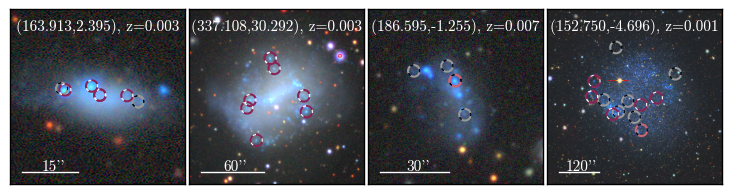

In [47]:
fig,ax = make_subplots(ncol=4,nrow=1,return_fig=True,plot_size=1.75,
                      col_spacing=[MARGIN_PAD/5]*5, row_spacing=[MARGIN_PAD, MARGIN_PAD])

for idx in range(4):

    cutout_ra, cutout_dec, gal_r50, sample_info, sample_ra, sample_dec = get_associated_tgid_info(targetids_ifu_eg[idx], main, zpix_iron)
    
    zred_i = float(main[main["TARGETID"] == targetids_ifu_eg[idx]]["Z"] )
    
    img_path = f"/pscratch/sd/v/virajvm/trash/dwarf_sparse_ifu_spec/data_{targetids_ifu_eg[idx]}.fits"
    
    cutout_size_pix = int(8*(gal_r50/0.262))
    
    print(cutout_size_pix)
    
    if os.path.exists(img_path):
        pass
    else:
        save_cutouts(cutout_ra,cutout_dec,img_path,session, size=cutout_size_pix, timeout = 120)
    
    img_data = fits.open(img_path)
    data_arr = img_data[0].data
    wcs = WCS(fits.getheader( img_path ))
    
    full_rgb, shift = process_img(data_arr, org_size=np.shape(data_arr)[1], cutout_size=int(5*(gal_r50/0.262)), return_shift=True)
    
    ax[idx].imshow(full_rgb,origin="lower",rasterized=True)

    xpixs, ypixs,_ = wcs.all_world2pix(sample_ra, sample_dec,0,1)
    
    xpixs, ypixs = xpixs-shift, ypixs-shift
    
    for i in range(len(xpixs)):
        color_i = sample_colors[sample_info[i]]
        if sample_info[i] == "BGS_BRIGHT":
            back_color="white"
        else:
            back_color="k"
        ax[idx].scatter(xpixs[i], ypixs[i], edgecolor = back_color, s= 70, facecolor = "None",lw=1.5/2,ls = "-",alpha=1 )
        ax[idx].scatter(xpixs[i], ypixs[i], edgecolor = color_i, s= 70, facecolor = "None",lw=3/2,ls = "--",alpha=1 )
        
    
    #add a 15'' bar?
    if idx == 0:
        bar_arcsec = 15
    elif idx == 1:
        bar_arcsec = 60
    elif idx == 3:
        bar_arcsec = 120
    else:
        bar_arcsec = 30
        
    bar_frac = bar_arcsec/(np.shape(full_rgb)[1] * 0.262 )
    
    # Define bar length in fraction of axes width (e.g., 0.3 = 30% of width)
    x_start_frac = 0.07  # 7% from left
    y_start_frac = 0.07  # 7% from bottom

    ax[idx].text( x_start_frac + 0.55*bar_frac, y_start_frac*1.15, f"{bar_arcsec}''",color = "white",
                 ha="center",transform=ax[idx].transAxes)
    
    # Draw the scale bar in axes coordinates
    ax[idx].plot([x_start_frac, x_start_frac + bar_frac],
            [y_start_frac, y_start_frac],
            color='white', lw=1, transform=ax[idx].transAxes)
    
    ax[idx].text(0.5,0.95, rf"({cutout_ra:.3f},{cutout_dec:.3f}), z={zred_i:.3f}", transform = ax[idx].transAxes, 
               color = "white", ha="center",va="top")
    

# leave space at bottom
fig.subplots_adjust(bottom=0.2)

# define start in figure fraction coordinates
# x_start = 0.1   # 10% from left
# y_start = 0.05  # 5% from bottom of figure
# dx = 0.15       # spacing between legend items

# for i, samp in enumerate(all_samps):
#     color_i = sample_colors[samp]
#     if samp == "BGS_BRIGHT":
#         back_color = "white"
#     else:
#         back_color = "k"

#     # plot hollow circle using ax[0], but transform to figure coordinates
#     ax[0].scatter(2, -0.5, s=400, facecolor='None', edgecolor=back_color,
#                   lw=1.5, transform=ax[0].transAxes, zorder=5)
#     ax[0].scatter(2, -0.5, s=400, facecolor='None', edgecolor=color_i,
#                   lw=3, ls='--', transform=ax[0].transAxes, zorder=6)

#     # add label next to it
#     # fig.text(x_start + i*dx + 0.02, y_start, samp, va='center', ha='left', fontsize=16, color='k')


for axi in ax:
    axi.set_xticks([])
    axi.set_yticks([])

plt.savefig(f"/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/sparse_ifu_examples.pdf")    
plt.show()